In [ ]:
#import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
#1. load the MNIST dataset
mnist = fetch_openml('mnist_784')

In [ ]:
#2. split the dataset into features (X) and (y)
X = mnist.data
y = mnist.target

In [ ]:
#3. split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#4. initializing the decision tree classifier
dtc = DecisionTreeClassifier( random_state=42, max_depth=10)

In [ ]:
#5. train the classifier
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
#6. make peridiction on the test set
y_pred = dtc.predict(X_test)

In [ ]:
#7. calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy:, {accuracy*100:.2f}%' )

Accuracy:, 85.83%


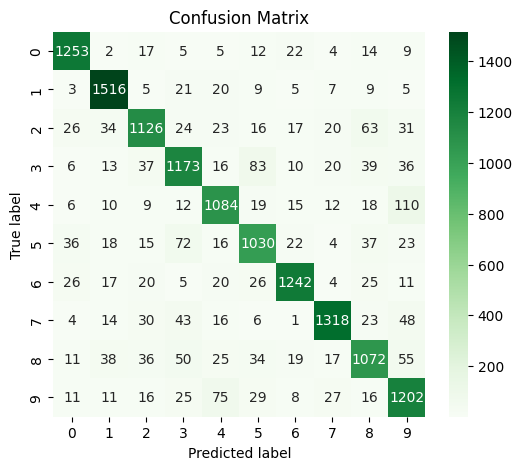

In [ ]:
#8. plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [ ]:
#9. print the classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1343
           1       0.91      0.95      0.93      1600
           2       0.86      0.82      0.84      1380
           3       0.82      0.82      0.82      1433
           4       0.83      0.84      0.84      1295
           5       0.81      0.81      0.81      1273
           6       0.91      0.89      0.90      1396
           7       0.92      0.88      0.90      1503
           8       0.81      0.79      0.80      1357
           9       0.79      0.85      0.81      1420

    accuracy                           0.86     14000
   macro avg       0.86      0.86      0.86     14000
weighted avg       0.86      0.86      0.86     14000



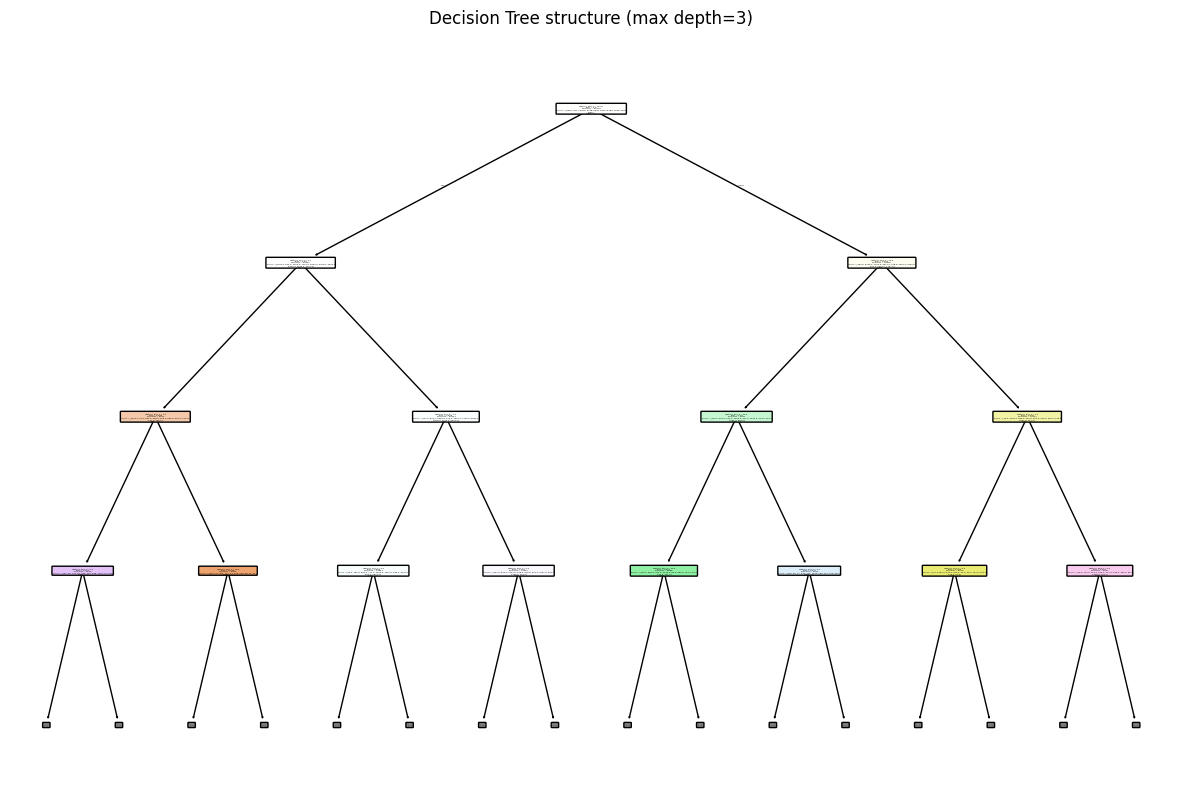

In [ ]:
#10 plot the decision tree
#10 plot the decision tree
plt.figure(figsize=(15, 10))
feature_names = [f'feature_{i}' for i in range(X_train.shape[1])] # creates a list with names like feature_0, feature_1
plot_tree(dtc, filled=True, rounded=True, feature_names=feature_names, class_names=dtc.classes_, max_depth=3)
plt.title('Decision Tree structure (max depth=3)')
plt.show()

In [ ]:
#11. visualzing some correct and incorrect prediction
correct_predictions = X_test[y_test == y_pred].iloc[0] # Use boolean indexing with square brackets and .iloc to select the first row
incorrect_predictions = X_test[y_test != y_pred].iloc[0]

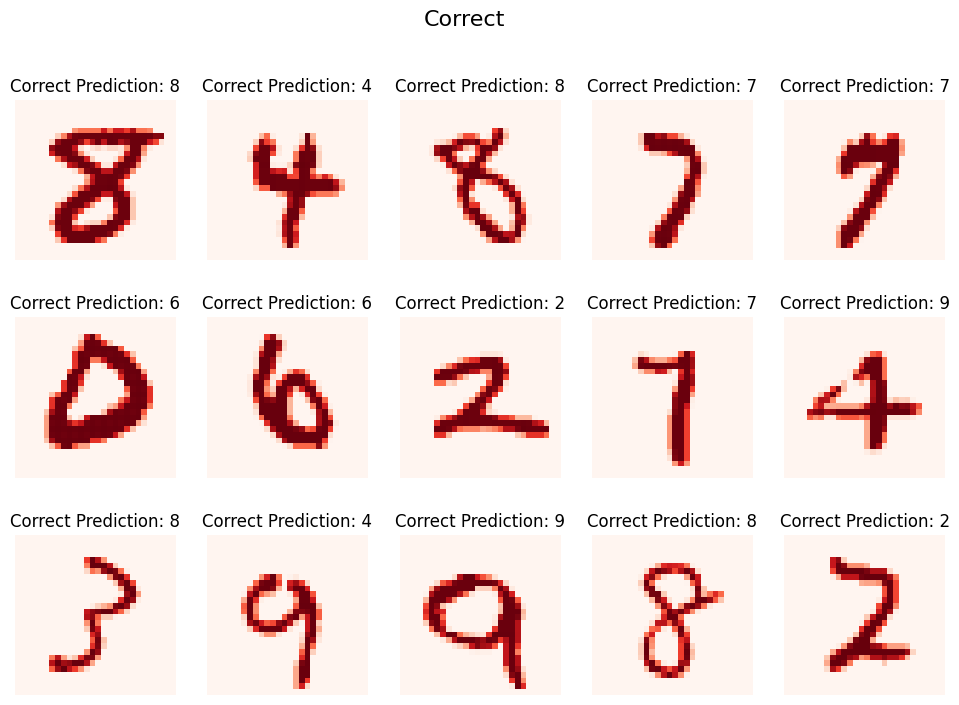

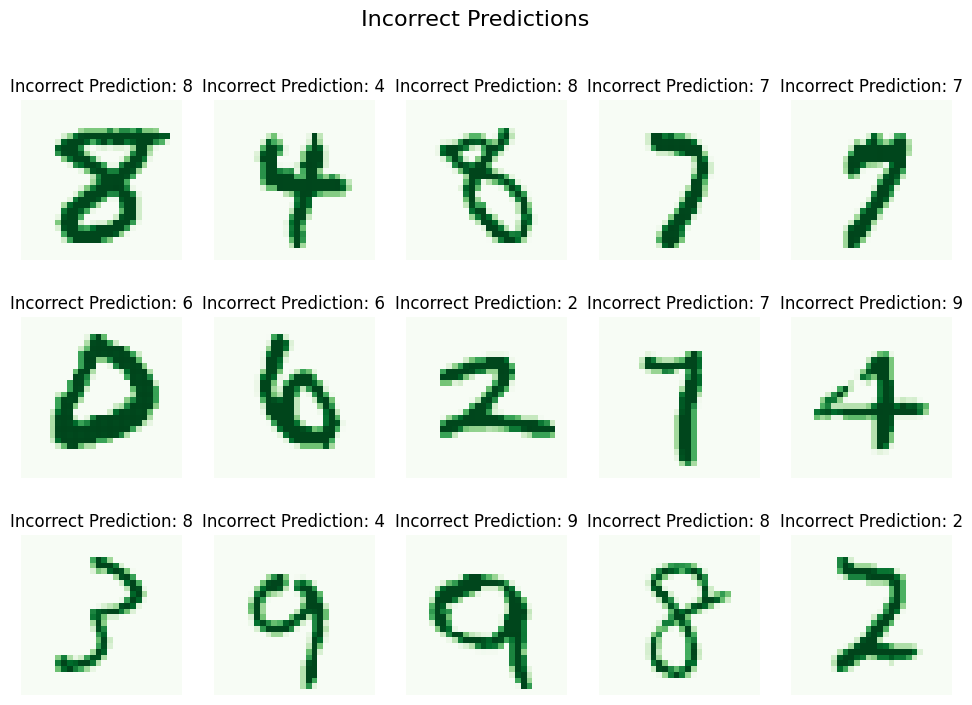

In [ ]:
# plot correct predictions
plt.figure(figsize=(12, 8))
plt.suptitle('Correct', fontsize=16)

# Iterate through the first 15 correct predictions only
# changed the loop to iterate only 15 times
for i in range(min(15, len(correct_predictions))):
    plt.subplot(3, 5, i + 1)
    # using i to access correct_predictions as index
    plt.imshow(X_test.iloc[i].values.reshape(28, 28), cmap='Reds')
    plt.title(f'Correct Prediction: {y_pred[i]}')
    plt.axis('off')
plt.show()

#plot incorrect prediction
plt.figure(figsize=(12, 8))
plt.suptitle(' Incorrect Predictions', fontsize=16)

# Iterate through the first 15 incorrect predictions only
# changed the loop to iterate only 15 times
for i in range(min(15, len(incorrect_predictions))):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test.iloc[i].values.reshape(28, 28), cmap='Greens')
    plt.title(f'Incorrect Prediction: {y_pred[i]}')
    plt.axis('off')

plt.show()


In [ ]:
# plot